## TASK -2: MOVIE RATING PREDICTION

Author: Sweety



Domain: DATA SCIENCE

In [1]:
#Import Liraries for data processing and modelling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India.csv


In [6]:
# Linking dataset into Colab
import io

imdb_df = pd.read_csv(io.BytesIO(uploaded['IMDb Movies India.csv']),encoding='unicode_escape')


In [7]:
# Dataset First Look
imdb_df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [8]:
imdb_df.shape

(15509, 10)

# Data Cleaning

In [10]:
imdb_df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [11]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [12]:
imdb_df.duplicated().sum()

np.int64(6)

In [13]:
imdb_df.dropna(inplace=True)

In [14]:
imdb_df.shape

(5659, 10)

In [15]:
imdb_df.isnull().sum()

,0
Name,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [16]:
imdb_df.drop_duplicates(inplace=True)

In [17]:
imdb_df.shape

(5659, 10)

In [19]:
imdb_df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

# Data Pre-Processing

- Data have to be processed to make more easier to derive insights from it and pre-processed will be more suitable while fitting the data into the algorithm.
- In this we have processed the data by column wise based on the requirement.

In [20]:
# Repalcing the bracket from year column
imdb_df['Year']=imdb_df['Year'].str.replace(r'[()]','',regex=True).astype(int)

In [21]:
# Remove the min word from 'Duration' column and covert all the values to numeric
imdb_df['Duration']=pd.to_numeric(imdb_df['Duration'].str.replace('min',''))

In [24]:
# Splitting the genre by,to keep only unique genres and replacing the null values with mode
imdb_df['Genre'] = imdb_df['Genre'].str.split(',')
imdb_df = imdb_df.explode('Genre')
imdb_df['Genre'] = imdb_df['Genre'].fillna(imdb_df['Genre'].mode()[0])



In [25]:
# Convert 'Votes' to numeric and replace the, to keep only numerical part
imdb_df['Votes']=pd.to_numeric(imdb_df['Votes'].str.replace(',',''))

In [26]:
# Checking the dataset is there any null values present and data types of the features present
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11979 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      11979 non-null  object 
 1   Year      11979 non-null  int64  
 2   Duration  11979 non-null  int64  
 3   Genre     11979 non-null  object 
 4   Rating    11979 non-null  float64
 5   Votes     11979 non-null  int64  
 6   Director  11979 non-null  object 
 7   Actor 1   11979 non-null  object 
 8   Actor 2   11979 non-null  object 
 9   Actor 3   11979 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.0+ MB


# Data Visualizing


- Visualization part is done to show the realtionships between the features present in the dataset.
- In the project, we have used multiple charts to see the realtions within components of data which involes in the result.

In [27]:
# Here we have created a histogram over the years in the data
year = px.histogram(imdb_df, x = 'Year', histnorm= 'probability density',nbins = 30)
year.show()

In [29]:
# Group data by year and calculate the average rating
avg_rating_by_year = imdb_df.groupby(['Year','Genre'])['Rating'].mean().reset_index()

# Get the top 10 genres
top_genres = imdb_df['Genre'].value_counts().head(10).index

# Filter the data to include only the top 3 genres
average_rating_by_year = avg_rating_by_year[avg_rating_by_year['Genre'].isin(top_genres)]

# Creating the line plot with Plotly Express
fig = px.line(avg_rating_by_year,x= 'Year', y='Rating',color= "Genre")

# Updating the details into the chart like title and hue
fig.update_layout(title='Average Rating by Year for Top Genres', xaxis_title='Year', yaxis_title='Average Rating')

# Show the plot
fig.show()

In [33]:
# This histogram shows the distribution of ratings and its probable density

rating_fig = px.histogram(
    imdb_df,
    x='Rating',
    histnorm='probability density',
    nbins=40
)

rating_fig.update_layout(
    title='Distribution of Rating',
    title_x=0.5,
    title_pad=dict(t=20),
    title_font=dict(size=20),
    xaxis_title='Rating',
    yaxis_title='Probability Density'
)

rating_fig.show()

# Feature Engineering


In [9]:
# Importing essential libraries for model building

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Droping Name column because it doesn't impact the outcome
imdb_df.drop('Name', axis = 1, inplace = True)

In [16]:
# Grouping the column with their average rating and then creating a new feature

genre_mean_rating = imdb_df.groupby('Genre')['Rating'].transform('mean')
imdb_df['Genre_mean_rating']= genre_mean_rating

director_mean_rating = imdb_df.groupby('Director')['Rating'].transform('mean')
imdb_df['Director_encoded'] = director_mean_rating

actor1_mean_rating = imdb_df.groupby('Actor 1')['Rating'].transform('mean')
imdb_df['Actor1_encoded'] = actor1_mean_rating

actor2_mean_rating = imdb_df.groupby('Actor 2')['Rating'].transform('mean')
imdb_df['Actor2_encoded'] = actor2_mean_rating

actor3_mean_rating = imdb_df.groupby('Actor 3')['Rating'].transform('mean')
imdb_df['Actor3_encoded'] = actor3_mean_rating

In [20]:
# Keeping predictor and target variables

X = imdb_df[['Year', 'Votes', 'Director', 'Genre_mean_rating',
             'Director_encoded', 'Actor1_encoded',
             'Actor2_encoded', 'Actor3_encoded']]

y = imdb_df['Rating']

In [23]:
# Splitting the dataset into training and testing parts

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# Model Buliding

In [33]:
# Building machine learning model

Model = LinearRegression()

Model.fit(X_train, y_train)

Model_pred = Model.predict(X_test)

In [34]:
# Evaluating the performance of model with evaluation metrics

print('The performace evaluation of Logistic Regression is below: ', '\n')
print('Mean squared error:', mean_squared_error(y_test, Model_pred))
print('Mean absolute error:', mean_absolute_error(y_test, Model_pred))
print('R2 score:',r2_score(y_test,Model_pred))

The performace evaluation of Logistic Regression is below:  

Mean squared error: 0.45173672331434583
Mean absolute error: 0.5011738829274817
R2 score: 0.7561919216554244


# Model Testing

In [35]:
X.head(5)

,Year,Votes,Genre_mean_rating,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded
1,2019.0,8,6.352082,7.000000,6.850000,7.000000,7.000000
3,2019.0,35,5.722500,4.400000,5.420000,4.400000,4.450000
5,1997.0,827,6.224490,5.358824,4.788889,5.786667,5.846154
6,2005.0,1086,6.820000,7.500000,5.356000,6.050000,6.500000
8,2012.0,326,5.463636,5.600000,5.600000,5.883333,5.600000


In [36]:
y.head(5)

,Rating
1,7.0
3,4.4
5,4.7
6,7.4
8,5.6


In [42]:
data = {
    'Year': [2019],
    'Votes': [36],
    'Genre_mean_rating': [5.8],
    'Director_encoded': [4.5],
    'Actor1_encoded': [5.3],
    'Actor2_encoded': [4.5],
    'Actor3_encoded': [4.8]
}

trail = pd.DataFrame(data)

# Same column order as training
trail = trail[
    ['Year', 'Votes', 'Genre_mean_rating',
     'Director_encoded', 'Actor1_encoded',
     'Actor2_encoded', 'Actor3_encoded']
]

print(trail)

   Year  Votes  Genre_mean_rating  Director_encoded  Actor1_encoded  \
0  2019     36                5.8               4.5             5.3   

   Actor2_encoded  Actor3_encoded  
0             4.5             4.8  


In [43]:
rating_predicted = Model.predict(trail)

print("Predicted Rating:", rating_predicted[0])

Predicted Rating: 4.439419259968781


In [44]:
# Model Evaluation

mae = mean_absolute_error(y_test, Model_pred)
mse = mean_squared_error(y_test, Model_pred)
r2 = r2_score(y_test, Model_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.5011738829274817
Mean Squared Error: 0.45173672331434583
R2 Score: 0.7561919216554244


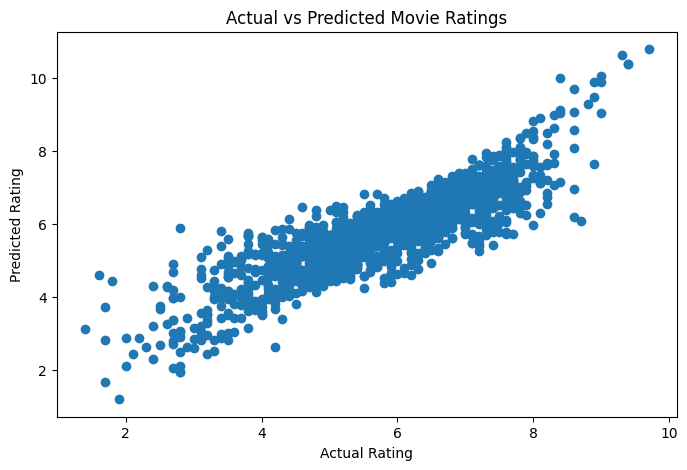

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, Model_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

 ## Conclusion



In this project, a Linear Regression model was developed to predict movie ratings using historical movie data. The dataset was cleaned and preprocessed before training the model. Features such as year, votes, genre-based rating, director encoding, and actor encodings were used for prediction.

The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The model's performance shows how machine learning can be used to estimate movie ratings from available movie-related features.